# GMDNN — Rede Neural Densa (MLP) para o GMD

Modelo **central do TCC**: MLP em PyTorch que prevê `gmd_kg_dia`. Pré-processamento compartilhado via `data_prep` (v3). Inclui **grid search** de hiperparâmetros (CV 10-fold), **leave-one-property-out** (robustez) e comparação com/sem **jitter** (augmentation).

## 1. Setup

In [1]:
import sys, copy
sys.path.append("support_scripts")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from itertools import product
import data_prep as dp

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(dp.SEED); np.random.seed(dp.SEED)
print("device:", device)

device: cuda


## 2. Dados (via `data_prep` v3)

In [2]:
d = dp.get_data()
df, groups = d["df"], d["groups"]
scale_cols, TARGET = d["scale_cols"], dp.TARGET
print(f"{len(df)} animais | {len(scale_cols)} preditores")
print("preditores:", scale_cols)
print("grupos:", groups.value_counts().to_dict())

245 animais | 9 preditores
preditores: ['peso_entrada_kg', 'dias_permanencia', 'proporcao_bos_indicus_pct', 'media_suplemento_kg_dia', 'pb_suplemento_pct', 'media_proteina_bruta_forragem_pct', 'numero_eventos_transporte', 'temperatura_media_c', 'proporcao_ciclo_seca']
grupos: {'elvis': 113, 'humberto': 71, 'sonico': 61}


## 3. Rede — `GMDNN`

Blocos Linear → BatchNorm → ReLU → Dropout; saída linear de 1 neurônio.

In [3]:
class GMDNN(nn.Module):
    def __init__(self, n_in, hidden=(64, 32), p_drop=0.1, batchnorm=True):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers += [nn.ReLU(), nn.Dropout(p_drop)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4. Treino + avaliação (por fold)

Cada chamada: separa uma validação interna do treino p/ **early stopping**, opcionalmente aplica **jitter** só no treino, escalona (fit só no treino, X e y), treina com Huber loss + LR scheduler, e avalia em `eval_df` **real** (métricas em kg/dia, predição destransformada).

In [4]:
def train_eval(train_df, eval_df, cfg, augment=False, seed=dp.SEED):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_df, es_df = train_test_split(train_df, test_size=0.15, random_state=seed)
    if augment:
        tr_df = dp.augment_train(tr_df, k=cfg.get('k', 2), seed=seed)

    xs = StandardScaler().fit(tr_df[scale_cols])
    ys = StandardScaler().fit(tr_df[[TARGET]])
    def tens(dd):
        X = torch.tensor(xs.transform(dd[scale_cols]), dtype=torch.float32)
        y = torch.tensor(ys.transform(dd[[TARGET]]), dtype=torch.float32)
        return X, y
    Xtr, ytr = tens(tr_df); Xes, yes = tens(es_df)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True, drop_last=True)

    model = GMDNN(len(scale_cols), cfg['hidden'], cfg['p_drop'], cfg['batchnorm']).to(device)
    opt = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg.get('wd', 0.0))
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=8)
    crit = nn.SmoothL1Loss()
    Xes_d, yes_d = Xes.to(device), yes.to(device)
    best, best_state, wait = 1e9, None, 0
    for epoch in range(300):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = crit(model(Xes_d), yes_d).item()
        sched.step(v)
        if v < best - 1e-5:
            best, best_state, wait = v, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= 20:
                break
    model.load_state_dict(best_state)

    model.eval()
    Xe = torch.tensor(xs.transform(eval_df[scale_cols]), dtype=torch.float32).to(device)
    with torch.no_grad():
        pred = ys.inverse_transform(model(Xe).cpu().numpy()).ravel()
    return dp.metrics(eval_df[TARGET].values, pred), pred


def cv_evaluate(cfg, augment=False):
    fold_m = []
    for tr, va in dp.get_cv().split(df):
        m, _ = train_eval(df.iloc[tr], df.iloc[va], cfg, augment=augment)
        fold_m.append(m)
    return dp.summarize(fold_m)[0]

## 5. Grid search (CV 10-fold) — grade expandida

Arquitetura × dropout × **learning-rate (até 1e-2)** × BatchNorm × **weight_decay**. Seleção pela melhor R² média no CV 10-fold. A grade anterior teve ótimo nas bordas (lr máx, dropout 0, BN off), daí a expansão. (48 configs.)

In [5]:
GRID = dict(
    hidden=[(64, 32), (128, 64, 32)],
    p_drop=[0.0, 0.1],
    lr=[3e-3, 5e-3, 1e-2],
    batchnorm=[False, True],
    wd=[0.0, 1e-4],
)
keys = list(GRID)
rows = []
for vals in product(*GRID.values()):
    cfg = dict(zip(keys, vals))
    cv = cv_evaluate(cfg, augment=False)
    rows.append({**cfg, 'MAE': round(cv.MAE.mean(), 4),
                 'R2': round(cv.R2.mean(), 4), 'R2_std': round(cv.R2.std(), 3)})
    print(f"{cfg}  ->  R2={rows[-1]['R2']:.3f}  MAE={rows[-1]['MAE']:.4f}")

res = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
res

{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.003, 'batchnorm': False, 'wd': 0.0}  ->  R2=0.653  MAE=0.0393


{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.003, 'batchnorm': False, 'wd': 0.0001}  ->  R2=0.649  MAE=0.0402


{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.003, 'batchnorm': True, 'wd': 0.0}  ->  R2=0.691  MAE=0.0367


{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.003, 'batchnorm': True, 'wd': 0.0001}  ->  R2=0.704  MAE=0.0368


{'hidden': (64, 32), 'p_drop': 0.0, 'lr': 0.005, 'batchnorm': False, 'wd': 0.0}  ->  R2=0.644  MAE=0.0392


...

{'hidden': (128, 64, 32), 'p_drop': 0.1, 'lr': 0.01, 'batchnorm': False, 'wd': 0.0}  ->  R2=0.693  MAE=0.0395


{'hidden': (128, 64, 32), 'p_drop': 0.1, 'lr': 0.01, 'batchnorm': False, 'wd': 0.0001}  ->  R2=0.705  MAE=0.0378


{'hidden': (128, 64, 32), 'p_drop': 0.1, 'lr': 0.01, 'batchnorm': True, 'wd': 0.0}  ->  R2=0.758  MAE=0.0365


{'hidden': (128, 64, 32), 'p_drop': 0.1, 'lr': 0.01, 'batchnorm': True, 'wd': 0.0001}  ->  R2=0.763  MAE=0.0351


,hidden,p_drop,lr,batchnorm,wd,MAE,R2,R2_std
0,"(128, 64, 32)",0.0,0.010,True,0.0000,0.0300,0.8050,0.121
1,"(128, 64, 32)",0.0,0.005,True,0.0000,0.0303,0.7963,0.128
2,"(128, 64, 32)",0.0,0.010,True,0.0001,0.0294,0.7962,0.176
3,"(128, 64, 32)",0.0,0.005,True,0.0001,0.0321,0.7837,0.119
4,"(128, 64, 32)",0.0,0.005,False,0.0001,0.0317,0.7834,0.187
5,"(128, 64, 32)",0.0,0.003,True,0.0000,0.0324,0.7833,0.136
6,"(128, 64, 32)",0.0,0.003,True,0.0001,0.0317,0.7795,0.144
7,"(128, 64, 32)",0.0,0.010,False,0.0001,0.0341,0.7645,0.188
8,"(128, 64, 32)",0.1,0.010,True,0.0001,0.0351,0.7627,0.159
9,"(64, 32)",0.0,0.010,False,0.0000,0.0329,0.7625,0.200


## 6. Melhor configuração — CV com e sem jitter

Jitter = ruído de medição **feature-only** (perturba `peso_entrada`/`temperatura`, mantém o GMD real). **Nota metodológica:** rederivar o alvo a partir do `peso_entrada` (que é feature e entra em `gmd=(peso_saida−peso_entrada)/dias`) acopla feature↔alvo e **infla o R² artificialmente** (um diagnóstico levou 0,67→0,81 só aumentando o ruído, enquanto o feature-only fica ~0,68). Por isso usamos feature-only — o número honesto.

In [6]:
best = {k: res.iloc[0][k] for k in keys}
print('melhor config:', best)

cv_plain = cv_evaluate(best, augment=False)
cv_aug = cv_evaluate(best, augment=True)
tab = pd.DataFrame({
    'sem jitter': cv_plain.agg(['mean', 'std']).stack(),
    'com jitter': cv_aug.agg(['mean', 'std']).stack(),
}).round(4)
base = dp.baseline_mae(df[TARGET], df[TARGET])
print(f'baseline MAE (média): {base:.4f}')
tab

melhor config: {'hidden': (128, 64, 32), 'p_drop': np.float64(0.0), 'lr': np.float64(0.01), 'batchnorm': np.True_, 'wd': np.float64(0.0)}


baseline MAE (média): 0.0793


sem jitter  com jitter
mean MAE       0.0300      0.0311
     RMSE      0.0469      0.0466
     R2        0.8050      0.8009
std  MAE       0.0071      0.0096
     RMSE      0.0134      0.0154
     R2        0.1209      0.1374

### Arquitetura da melhor rede (`torchinfo`)

In [7]:
n_in = len(scale_cols)
modelo_final = GMDNN(n_in, best["hidden"], best["p_drop"], best["batchnorm"])
summary(modelo_final, input_size=(32, n_in),
        col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
GMDNN                                    [32, 9]                   [32, 1]                   --
├─Sequential: 1-1                        [32, 9]                   [32, 1]                   --
│    └─Linear: 2-1                       [32, 9]                   [32, 128]                 1,280
│    └─BatchNorm1d: 2-2                  [32, 128]                 [32, 128]                 256
│    └─ReLU: 2-3                         [32, 128]                 [32, 128]                 --
│    └─Dropout: 2-4                      [32, 128]                 [32, 128]                 --
│    └─Linear: 2-5                       [32, 128]                 [32, 64]                  8,256
│    └─BatchNorm1d: 2-6                  [32, 64]                  [32, 64]                  128
│    └─ReLU: 2-7                         [32, 64]                  [32, 64]                  --
│    └─Dropout: 2-8        

## 7. Robustez — leave-one-property-out (3 fazendas)

In [8]:
lopo = []
for tr, te, p in dp.leave_one_property_out(groups):
    m, _ = train_eval(df.iloc[tr], df.iloc[te], best, augment=False)
    m['testa'] = p
    lopo.append(m)
lopo_df = pd.DataFrame(lopo)[['testa', 'MAE', 'RMSE', 'R2']].round(4)
print('Treina numa fazenda, testa na outra:')
lopo_df

Treina numa fazenda, testa na outra:


,testa,MAE,RMSE,R2
0,elvis,0.0742,0.0970,-0.1212
1,sonico,0.7253,0.9396,-154.5066
2,humberto,0.1274,0.1570,0.1162


## 8. Predito × real (out-of-fold) e salvar resultado

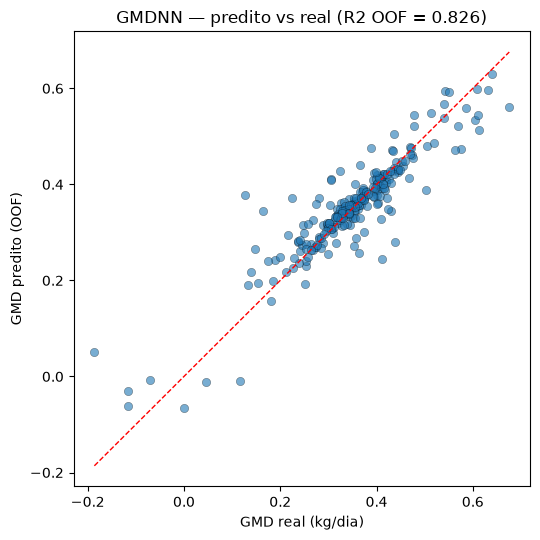

salvo em results/model_comparison.csv


In [9]:
y_true = df[TARGET].values.copy()
y_oof = np.zeros(len(df))
for tr, va in dp.get_cv().split(df):
    _, pred = train_eval(df.iloc[tr], df.iloc[va], best, augment=False)
    y_oof[va] = pred

r2_oof = dp.metrics(y_true, y_oof)['R2']
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_true, y_oof, alpha=0.6, edgecolor='k', linewidth=.3)
lims = [min(y_true.min(), y_oof.min()), max(y_true.max(), y_oof.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('GMD real (kg/dia)'); ax.set_ylabel('GMD predito (OOF)')
ax.set_title(f'GMDNN — predito vs real (R2 OOF = {r2_oof:.3f})')
plt.tight_layout(); plt.show()

lopo_mean = {'MAE': lopo_df.MAE.mean(), 'R2': lopo_df.R2.mean()}
best_cv = cv_aug if cv_aug.R2.mean() > cv_plain.R2.mean() else cv_plain
dp.save_result('MLP_DNN', best_cv, ext_metrics=lopo_mean)
print('salvo em', dp.RESULTS_PATH)

## 9. Notas

- **Grid search** seleciona a config por R² média no CV 10-fold; mesmo esquema será usado nos outros modelos (comparação justa).
- **Jitter feature-only** (honesto) só entra no treino; avaliação sempre em dado real. Aqui quase não move a rede — o teto vem do tamanho do dataset (N=245).
- **LOPO** é o teste severo de validade externa entre as 3 fazendas (treina 2 / testa a 3ª).
- Resultado gravado em `results/model_comparison.csv` (via `dp.save_result`).